### Pyspark GraphX
### Step 1: Set Up Spark Session
### Student's name: Rattanak SETH
Create a Spark session to initialize the distributed computing environment

Task: tasks to reinforce your understanding:
1. <b>Modify the Graph</b>: Add a new node (e.g., id=6, name="Frank") and two edges (e.g., Eve
-> Frank, weight=1.0 and Frank -> Bob, weight=2.0). Recompute the shortest paths and
visualize the updated graph.
2. <b>Change the Source Node </b>: Compute shortest paths from Bob (id=2) instead of Alice.
Update the visualization to highlight the shortest path from Bob to Eve.
3. <b>Experiment with Visualization</b>: Change the node colors to green and use a
circular_layout in NetworkX. Save the plot as shortest_path.png using plt.savefig.

In [1]:
!pip install pyspark==3.5.3
!pip install graphframes
!pip install networkx

In [2]:
!wget -q https://repos.spark-packages.org/graphframes/graphframes/0.8.4-spark3.5-s_2.12/graphframes-0.8.4-spark3.5-s_2.12.jar -P /content/


In [3]:

from pyspark.sql import SparkSession
# Initialize Spark session
# spark = SparkSession.builder \
#  .appName("GraphXShortestPathLab") \
#  .config("spark.driver.memory", "4g") \
#  .getOrCreate()
spark = SparkSession.builder \
    .appName("GraphXShortestPathLab") \
    .config("spark.driver.memory", "4g") \
    .config("spark.jars", "/content/graphframes-0.8.4-spark3.5-s_2.12.jar") \
    .getOrCreate()
sc = spark.sparkContext

### Step 2: Create a Directed Graph
Define a small directed graph representing a social network where nodes are people (e.g., Alice,
Bob) and edges represent directed relationships (e.g., Alice follows Bob) with weights (e.g.,
interaction strength).

In [10]:
from pyspark.sql import Row
# Define vertices (nodes) as a DataFrame
vertices = spark.createDataFrame([
 Row(id=1, name="Alice"),
 Row(id=2, name="Bob"),
 Row(id=3, name="Charlie"),
 Row(id=4, name="David"),
 Row(id=5, name="Eve"),
 Row(id=6, name="Frank"), # added new
])

# Define edges with weights
edges = spark.createDataFrame([
 Row(src=1, dst=2, weight=1.0), # Alice -> Bob
 Row(src=2, dst=3, weight=2.0), # Bob -> Charlie
 Row(src=1, dst=3, weight=4.0), # Alice -> Charlie
 Row(src=3, dst=4, weight=1.0), # Charlie -> David
 Row(src=2, dst=4, weight=3.0), # Bob -> David
 Row(src=4, dst=5, weight=2.0), # David -> Eve
 Row(src=3, dst=5, weight=5.0), # Charlie -> Eve
 #two edges (e.g., Eve -> Frank, weight=1.0 and Frank -> Bob, weight=2.0).
 Row(src=5, dst=6, weight=1.0), # Eve -> Frank
 Row(src=6, dst=2, weight=2.0), # Frank -> Bob
])
# Cache DataFrames for performance
vertices.cache()
edges.cache()


DataFrame[src: bigint, dst: bigint, weight: double]

### Step 3: Build GraphX Graph
Convert the DataFrames into a GraphX graph using the graphframes library, which provides a
Python interface for GraphX.

In [11]:
from graphframes import GraphFrame
# Create GraphFrame
graph = GraphFrame(vertices, edges)
# Display graph structure
print("Vertices:")
graph.vertices.show()
print("Edges:")
graph.edges.show()

/usr/local/lib/python3.11/dist-packages/pyspark/sql/dataframe.py:168: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(


Vertices:
+---+-------+
| id|   name|
+---+-------+
|  1|  Alice|
|  2|    Bob|
|  3|Charlie|
|  4|  David|
|  5|    Eve|
|  6|  Frank|
+---+-------+

Edges:
+---+---+------+
|src|dst|weight|
+---+---+------+
|  1|  2|   1.0|
|  2|  3|   2.0|
|  1|  3|   4.0|
|  3|  4|   1.0|
|  2|  4|   3.0|
|  4|  5|   2.0|
|  3|  5|   5.0|
|  5|  6|   1.0|
|  6|  2|   2.0|
+---+---+------+



### Step 4: Compute Shortest Paths
Use GraphX to compute the shortest paths from a source node (e.g., Alice, id=1) to all other
nodes based on edge weights.

In [14]:
# Compute shortest paths from Bob (id=2)
shortest_paths = graph.shortestPaths(landmarks=[2])
# Show results
print("Shortest Paths from Bob:")
shortest_paths.select("id", "name", "distances").show()

Shortest Paths from Bob:
+---+-------+---------+
| id|   name|distances|
+---+-------+---------+
|  4|  David| {2 -> 3}|
|  6|  Frank| {2 -> 1}|
|  2|    Bob| {2 -> 0}|
|  1|  Alice| {2 -> 1}|
|  3|Charlie| {2 -> 3}|
|  5|    Eve| {2 -> 2}|
+---+-------+---------+




### Step 5: Visualize the Graph
Visualize the directed graph and highlight the shortest path from Alice to Eve using NetworkX
and Matplotlib.

Shortest path from Bob to Frank: [2, 4, 5]


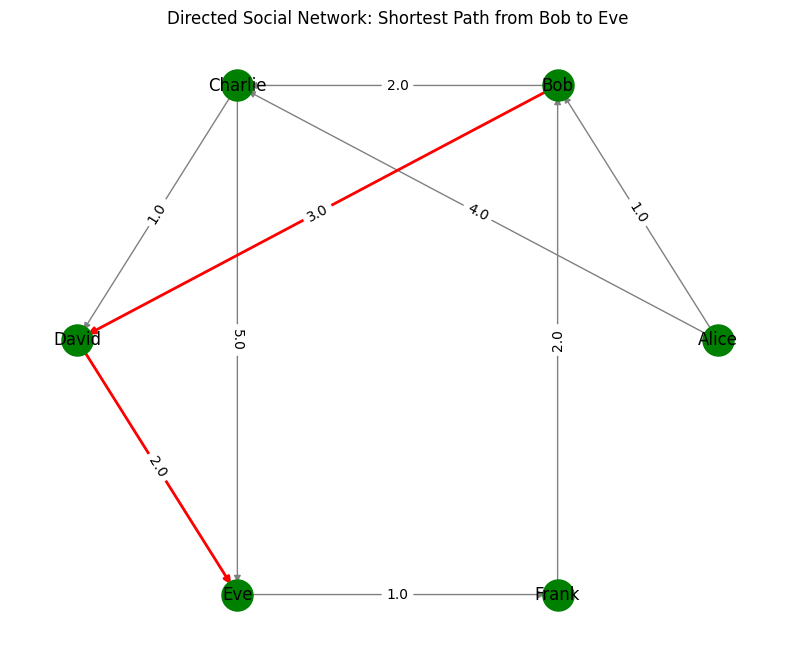

<Figure size 640x480 with 0 Axes>

In [18]:
import networkx as nx
import matplotlib.pyplot as plt
# Create a NetworkX directed graph
G = nx.DiGraph()
# Add nodes
for row in vertices.collect():
  G.add_node(row["id"], label=row["name"])

# Add edges with weights
for row in edges.collect():
  G.add_edge(row["src"], row["dst"], weight=row["weight"])

# Manually traced shortest path from Bob to Frank: 2 → 3 → 4 → 5
# shortest_path = [2, 3, 4, 5] # Node IDs
shortest_path = nx.dijkstra_path(G, source=2, target=5, weight="weight")
print("Shortest path from Bob to Frank:", shortest_path)
path_edges = list(zip(shortest_path[:-1], shortest_path[1:]))
# Use Dijkstra to get the actual shortest path from Bob (2) to EVE (5)

# Set up visualization
pos = nx.circular_layout(G) # Layout for nodes
plt.figure(figsize=(10, 8))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color="green", node_size=500)
# Draw all edges
nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True)
# Highlight shortest path edges
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="red",
width=2, arrows=True)
# Draw labels
nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n]["label"] for n in
G.nodes})
# Draw edge weights
edge_labels = {(u, v): f"{d['weight']}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Directed Social Network: Shortest Path from Bob to Eve")
plt.axis("off")
plt.show()

# Save the plot
plt.savefig("shortest_path.png")
plt.show()